# Script for comparing simulated and measured voltage and temperature curves

In [158]:
import numpy as np
from matplotlib import pyplot as plt
import matplotlib
import pandas as pd
import matplotlib.ticker as tck
from mpl_toolkits.axes_grid1.inset_locator import mark_inset
from pathlib import Path

# Global plotting defaults used by all figures in this notebook.
FONT = {"size": 12}
matplotlib.rc("font", **FONT)
plt.rcParams["axes.labelsize"] = 14

# Directory containing the exported EMSI CSV files for this study.
folder = Path("../raw_data")

## Voltage profile during charging with/without electrolyte motion
##### The simulated charge voltage profiles at different C-rates match well with experiments. The model with poroelasticity shows higher overpotential near the end-of-charge due to porosity reduction, especially at 1C

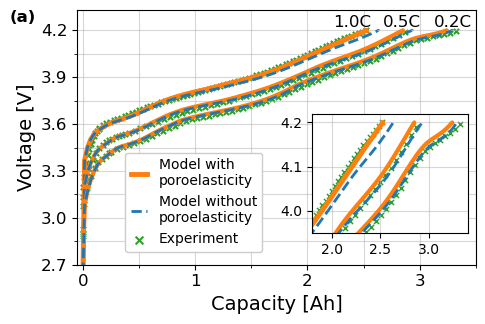

In [161]:
fig, ax = plt.subplots(1, 1,  figsize=(5, 3.4))

### 1C charging
df_comsol = pd.read_csv(folder / "simulated_voltage_charge_C_rate_1.csv", skiprows=8, names=["Q", "V"], header=None, sep=',')
df_comsol.Q -= df_comsol.Q.iloc[0]
df_comsol_noflow = pd.read_csv(folder / "simulated_voltage_charge_noflow_C_rate_1.csv", skiprows=8, names=["Q", "V"], header=None, sep=',')
df_comsol_noflow.Q -= df_comsol_noflow.Q.iloc[0]
df_exp = pd.read_csv(folder / "measured_voltage_1C_charge.txt", names=["Q", "V"], header=None, sep='       ', engine='python')
plt.plot(df_comsol.Q, df_comsol.V, label="Model with" "\n" "poroelasticity", color='tab:orange', linewidth=3.5)
plt.plot(df_comsol_noflow.Q, df_comsol_noflow.V, label="Model without" "\n" "poroelasticity", color='tab:blue', linestyle='--', linewidth=2.0)
plt.scatter(df_exp.Q[:200:15], df_exp.V[:200:15], label="Experiment", marker='x', s=14, c="tab:green")
plt.scatter(df_exp.Q[200::35], df_exp.V[200::35], marker='x', s=14, c="tab:green")

# 0.5C charging
df_comsol = pd.read_csv(folder / "simulated_voltage_charge_C_rate_0.5.csv", skiprows=8, names=["Q", "V"], header=None, sep=',')
df_comsol.Q -= df_comsol.Q.iloc[0]
df_comsol_noflow = pd.read_csv(folder / "simulated_voltage_charge_noflow_C_rate_0.5.csv", skiprows=8, names=["Q", "V"], header=None, sep=',')
df_comsol_noflow.Q -= df_comsol_noflow.Q.iloc[0]
df_exp = pd.read_csv(folder / "measured_voltage_0.5C_charge.txt", names=["Q", "V"], header=None, sep='       ', engine='python')
plt.plot(df_comsol.Q, df_comsol.V, color='tab:orange', linestyle='-', linewidth=3.)
plt.plot(df_comsol_noflow.Q, df_comsol_noflow.V, color='tab:blue', linestyle='--', linewidth=2.0)
plt.scatter(df_exp.Q[:400:25], df_exp.V[:400:25], marker='x', s=14, c="tab:green")
plt.scatter(df_exp.Q[400::45], df_exp.V[400::45], marker='x', s=14, c="tab:green")

# 0.2C charging
df_comsol = pd.read_csv(folder / "simulated_voltage_charge_C_rate_0.2.csv", skiprows=8, names=["Q", "V"], header=None, sep=',')
df_comsol.Q -= df_comsol.Q.iloc[0]
df_comsol_noflow = pd.read_csv(folder / "simulated_voltage_charge_noflow_C_rate_0.2.csv", skiprows=8, names=["Q", "V"], header=None, sep=',')
df_comsol_noflow.Q -= df_comsol_noflow.Q.iloc[0]
df_exp = pd.read_csv(folder / "measured_voltage_0.2C_charge.txt", names=["Q", "V"], header=None, sep='       ', engine='python')
plt.plot(df_comsol.Q, df_comsol.V, color='tab:orange', linestyle='-', linewidth=3.0)
plt.plot(df_comsol_noflow.Q, df_comsol_noflow.V, color='tab:blue', linestyle='--', linewidth=2.0)
plt.scatter(df_exp.Q[:300:35], df_exp.V[:300:35], marker='x', s=14, c="tab:green")
plt.scatter(df_exp.Q[300::55], df_exp.V[300::55], marker='x', s=14, c="tab:green")


plt.ylim(2.7, 4.33)
plt.xlabel("Capacity [Ah]")
plt.ylabel("Voltage [V]")
plt.legend(loc=(0.12, 0.05), markerscale=1.5, framealpha=1, handlelength=1.2, fontsize=10)
plt.grid(alpha=0.5)
plt.text(2.23,4.22,"1.0C", color='black', fontsize=12)
plt.text(2.67,4.22,"0.5C", color='black', fontsize=12)
plt.text(3.13,4.22,"0.2C", color='black', fontsize=12)
plt.yticks(np.arange(2.7, 4.21, step=0.3))
plt.xticks(np.arange(0, 3.01, step=1.0))

ax.grid(which="minor", alpha=0.5)
ax.xaxis.set_minor_locator(tck.AutoMinorLocator(n=2))
ax.yaxis.set_minor_locator(tck.AutoMinorLocator(n=2))

numbering = (-0.65, "(a)")
if numbering != None:
    ax.text(numbering[0], ax.get_ylim()[1], numbering[1], weight="bold", verticalalignment="top")
plt.xlim(-0.05, 3.5)
plt.tight_layout()

# --- make inset ---
fig.canvas.draw()
leg = ax.get_legend()
renderer = fig.canvas.get_renderer()

bbox_disp = leg.get_window_extent(renderer=renderer)
bbox_ax = bbox_disp.transformed(ax.transAxes.inverted())

# put inset in the legend's rectangle, with higher zorder than the legend
axins = ax.inset_axes(
    [bbox_ax.x0+0.47, bbox_ax.y0+0.075, bbox_ax.width*1.13, bbox_ax.height*1.2],
    transform=ax.transAxes,
    zorder=leg.get_zorder() + 1
)

# copy existing artists into the inset (lines + scatters)
for line in ax.lines:
    axins.plot(
        line.get_xdata(), line.get_ydata(),
        color=line.get_color(),
        linestyle=line.get_linestyle(),
        linewidth=line.get_linewidth(),
        marker=line.get_marker(),
        markersize=line.get_markersize(),
    )

for coll in ax.collections:
    offsets = coll.get_offsets()
    if offsets is None or len(offsets) == 0:
        continue
    ec = coll.get_edgecolors()
    fc = coll.get_facecolors()
    c = ec[0] if len(ec) else (fc[0] if len(fc) else "k")
    axins.scatter(
        offsets[:, 0], offsets[:, 1],
        s=coll.get_sizes()*0.99,
        marker="x",
        linewidths=coll.get_linewidths()*0.7,
        c=[c],
    )

axins.set_xlim(1.8, 3.5)
axins.set_ylim(4.0, 4.22)

# fewer ticks on x-axis + bigger font in inset
axins.set_xticks(np.arange(2,3.5, 0.5)) 
axins.set_yticks(np.arange(3.9,4.21, 0.1))
axins.tick_params(labelsize=10)
axins.set_xlim(1.8, 3.4)
axins.set_ylim(3.95, 4.22)
axins.grid(alpha=0.5)

plt.savefig("../plots/voltage_profile_verification_ch.png", format="png", dpi=500)


## Voltage profile during discharging with/without electrolyte motion
##### The simulated discharge voltage profiles at different C-rates match well with experiments. The model with poroelasticity shows higher overpotential near the beginning-of-discharge due to porosity reduction

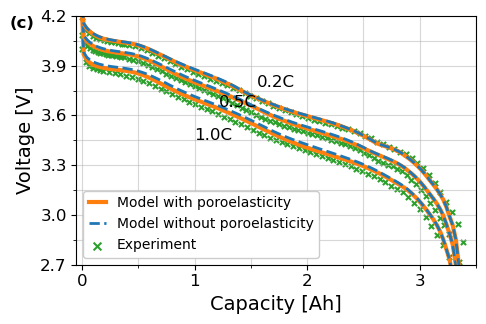

In [163]:
fig, ax = plt.subplots(1, 1,  figsize=(5, 3.4))

# 1C discharging
df_comsol = pd.read_csv(folder / "simulated_voltage_discharge_C_rate_1.csv", skiprows=8, names=["Q", "V"], header=None, sep=',')
df_comsol.Q -= df_comsol.Q.max()
df_comsol.Q *= -1
df_comsol_noflow = pd.read_csv(folder / "simulated_voltage_discharge_noflow_C_rate_1.csv", skiprows=8, names=["Q", "V"], header=None, sep=',')
df_comsol_noflow.Q -= df_comsol_noflow.Q.max()
df_comsol_noflow.Q *= -1
df_exp = pd.read_csv(folder / "measured_voltage_1C_discharge.txt", names=["Q", "V"], header=None, sep='       ', engine='python')
plt.plot(df_comsol.Q, df_comsol.V, label="Model with poroelasticity", color='tab:orange', linewidth=3.0)
plt.plot(df_comsol_noflow.Q, df_comsol_noflow.V, label="Model without poroelasticity", color='tab:blue', linestyle='--', linewidth=2.0)
plt.scatter(df_exp.Q[:200:35], df_exp.V[:200:35], label="Experiment", marker='x', s=14, c="tab:green")
plt.scatter(df_exp.Q[200::55], df_exp.V[200::55], marker='x', s=14, c="tab:green")

# 0.5C discharging
df_comsol = pd.read_csv(folder / "simulated_voltage_discharge_C_rate_0.5.csv", skiprows=8, names=["Q", "V"], header=None, sep=',')
df_comsol.Q -= df_comsol.Q.max()
df_comsol.Q *= -1
df_comsol_noflow = pd.read_csv(folder / "simulated_voltage_discharge_noflow_C_rate_0.5.csv", skiprows=8, names=["Q", "V"], header=None, sep=',')
df_comsol_noflow.Q -= df_comsol_noflow.Q.max()
df_comsol_noflow.Q *= -1
df_exp = pd.read_csv(folder / "measured_voltage_0.5C_discharge.txt", names=["Q", "V"], header=None, sep='       ', engine='python')
plt.plot(df_comsol.Q, df_comsol.V, color='tab:orange', linestyle='-', linewidth=3.0)
plt.plot(df_comsol_noflow.Q, df_comsol_noflow.V, color='tab:blue', linestyle='--', linewidth=2.0)
plt.scatter(df_exp.Q[:400:25], df_exp.V[:400:25], marker='x', s=14, c="tab:green")
plt.scatter(df_exp.Q[400::45], df_exp.V[400::45], marker='x', s=14, c="tab:green")

# 0.2C charging
df_comsol = pd.read_csv(folder / "simulated_voltage_discharge_C_rate_0.2.csv", skiprows=8, names=["Q", "V"], header=None, sep=',')
df_comsol.Q -= df_comsol.Q.max()
df_comsol.Q *= -1
df_comsol_noflow = pd.read_csv(folder / "simulated_voltage_discharge_noflow_C_rate_0.2.csv", skiprows=8, names=["Q", "V"], header=None, sep=',')
df_comsol_noflow.Q -= df_comsol_noflow.Q.max()
df_comsol_noflow.Q *= -1
df_exp = pd.read_csv(folder / "measured_voltage_0.2C_discharge.txt", names=["Q", "V"], header=None, sep='       ', engine='python')
plt.plot(df_comsol.Q, df_comsol.V, color='tab:orange', linestyle='-', linewidth=3.0)
plt.plot(df_comsol_noflow.Q, df_comsol_noflow.V, color='tab:blue', linestyle='--', linewidth=2.0)
plt.scatter(df_exp.Q[:400:35], df_exp.V[:400:35], marker='x', s=14, c="tab:green")
plt.scatter(df_exp.Q[400::55], df_exp.V[400::55], marker='x', s=14, c="tab:green")

plt.ylim(2.7, 4.2)
plt.xlabel("Capacity [Ah]")
plt.ylabel("Voltage [V]")
plt.legend(loc='lower left', markerscale=1.5, framealpha=1, handlelength=1.2, fontsize=10)
plt.grid(alpha=0.5)
plt.text(1.0,3.45,"1.0C", color='black', fontsize=12)
plt.text(1.22,3.65,"0.5C", color='black', fontsize=12)
plt.text(1.55,3.77,"0.2C", color='black', fontsize=12)

plt.yticks(np.arange(2.7, 4.21, step=0.3))
plt.xticks(np.arange(0, 3.01, step=1.0))

ax.grid(which="minor", alpha=0.5)
ax.xaxis.set_minor_locator(tck.AutoMinorLocator(n=2))
ax.yaxis.set_minor_locator(tck.AutoMinorLocator(n=2))

numbering = (-0.64, "(c)")
if numbering != None:
    ax.text(numbering[0], ax.get_ylim()[1], numbering[1], weight="bold", verticalalignment="top")
plt.xlim(-0.05, 3.5)

plt.tight_layout()
plt.savefig("../plots/voltage_profile_verification_dch.png", format="png", dpi=500)


## Temperature profile during charging with/without electrolyte motion
##### The simulated charge temperature profiles at different C-rates match well with experiments. The model with poroelasticity shows slightly higher temperature at 1C due to the higher overpotential

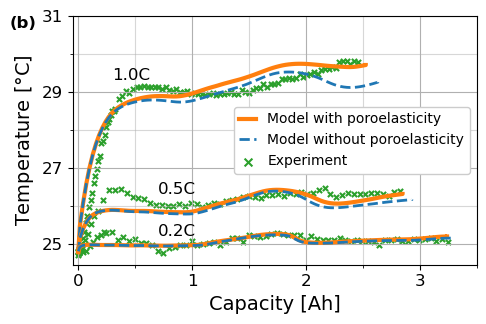

In [166]:
fig, ax = plt.subplots(1, 1,  figsize=(5, 3.4))


# 1C charging
df_comsol = pd.read_csv(folder / "simulated_temperature_charge_C_rate_1.csv", skiprows=8, names=["Q", "Temp"], header=None, sep=',')
df_comsol.Q -= df_comsol.Q.iloc[0]
df_comsol_noflow = pd.read_csv(folder / "simulated_temperature_charge_noflow_C_rate_1.csv", skiprows=8, names=["Q", "Temp"], header=None, sep=',')
df_comsol_noflow.Q -= df_comsol_noflow.Q.iloc[0]
df_exp = pd.read_csv(folder / "measured_temperature_1C_charge.txt", names=["Q", "Temp"], header=None, sep='       ', engine='python')
df_exp.Q *= 3.4
df_comsol.Temp -= df_comsol.Temp.iloc[0] - df_exp.Temp.iloc[0]
df_comsol_noflow.Temp -= df_comsol_noflow.Temp.iloc[0] - df_exp.Temp.iloc[0]
plt.plot(df_comsol.Q, df_comsol.Temp, label="Model with poroelasticity", color='tab:orange', linestyle='-', linewidth=3.0)
plt.plot(df_comsol_noflow.Q, df_comsol_noflow.Temp, label="Model without poroelasticity", color='tab:blue', linestyle='--', linewidth=2.0)
plt.scatter(df_exp.Q[:400:15], df_exp.Temp[:400:15], label="Experiment", marker='x', s=14, c="tab:green")
plt.scatter(df_exp.Q[400::35], df_exp.Temp[400::35], marker='x', s=14, c="tab:green")

# 0.5C charging
df_comsol = pd.read_csv(folder / "simulated_temperature_charge_C_rate_0.5.csv", skiprows=8, names=["Q", "Temp"], header=None, sep=',')
df_comsol.Q -= df_comsol.Q.iloc[0]
df_comsol_noflow = pd.read_csv(folder / "simulated_temperature_charge_noflow_C_rate_0.5.csv", skiprows=8, names=["Q", "Temp"], header=None, sep=',')
df_comsol_noflow.Q -= df_comsol_noflow.Q.iloc[0]
df_exp = pd.read_csv(folder / "measured_temperature_0.5C_charge.txt", names=["Q", "Temp"], header=None, sep='       ', engine='python')
df_exp.Q *= 3.4
df_comsol.Temp -= df_comsol.Temp.iloc[0] - df_exp.Temp.iloc[0]
df_comsol_noflow.Temp -= df_comsol_noflow.Temp.iloc[0] - df_exp.Temp.iloc[0]
plt.plot(df_comsol.Q, df_comsol.Temp, color='tab:orange', linestyle='-', linewidth=3.0)
plt.plot(df_comsol_noflow.Q, df_comsol_noflow.Temp, color='tab:blue', linestyle='--', linewidth=2.0)
plt.scatter(df_exp.Q[:200:25], df_exp.Temp[:200:25], marker='x', s=14, c="tab:green")
plt.scatter(df_exp.Q[200::45], df_exp.Temp[200::45], marker='x', s=14, c="tab:green")

# 0.2C charging
df_comsol = pd.read_csv(folder / "simulated_temperature_charge_C_rate_0.2.csv", skiprows=8, names=["Q", "Temp"], header=None, sep=',')
df_comsol.Q -= df_comsol.Q.iloc[0]
df_comsol_noflow = pd.read_csv(folder / "simulated_temperature_charge_noflow_C_rate_0.2.csv", skiprows=8, names=["Q", "Temp"], header=None, sep=',')
df_comsol_noflow.Q -= df_comsol_noflow.Q.iloc[0]
df_exp = pd.read_csv(folder / "measured_temperature_0.2C_charge.txt", names=["Q", "Temp"], header=None, sep='       ', engine='python')
df_exp.Q *= 3.4
df_comsol.Temp -= df_comsol.Temp.iloc[0] - df_exp.Temp.iloc[0]
df_comsol_noflow.Temp -= df_comsol_noflow.Temp.iloc[0] - df_exp.Temp.iloc[0]
plt.plot(df_comsol.Q, df_comsol.Temp, color='tab:orange', linestyle='-', linewidth=3.0)
plt.plot(df_comsol_noflow.Q, df_comsol_noflow.Temp, color='tab:blue', linestyle='--', linewidth=2.0)
plt.scatter(df_exp.Q[:300:35], df_exp.Temp[:300:35], marker='x', s=14, c="tab:green")
plt.scatter(df_exp.Q[300::55], df_exp.Temp[300::55], marker='x', s=14, c="tab:green")


plt.xlabel("Capacity [Ah]")
plt.ylabel(r"Temperature [$\degree$C]")
plt.legend(markerscale=1.5, framealpha=1, handlelength=1.2, fontsize=10)
plt.grid()
plt.text(0.3,29.3,"1.0C", color='black', fontsize=12)
plt.text(0.7,26.3,"0.5C", color='black', fontsize=12)
plt.text(0.7,25.2,"0.2C", color='black', fontsize=12)
plt.yticks(np.arange(25, 32, step=2.0))#, minor=True)
plt.xticks(np.arange(0, 3.01, step=1.0))

ax.grid(which="minor", alpha=0.5)
ax.xaxis.set_minor_locator(tck.AutoMinorLocator(n=2))
ax.yaxis.set_minor_locator(tck.AutoMinorLocator(n=2))
numbering = (-0.6, "(b)")
if numbering != None:
    ax.text(numbering[0], ax.get_ylim()[1], numbering[1], weight="bold", verticalalignment="top")
plt.xlim(-0.05, 3.5)

plt.tight_layout()
plt.savefig("../plots/temperature_profile_verification_ch.png", format="png", dpi=500)


## Temperature profile during discharging with/without electrolyte motion
##### The simulated discharge temperature profiles at different C-rates match well with experiments. The model with poroelasticity shows slightly higher temperature at 1C due to the higher overpotential

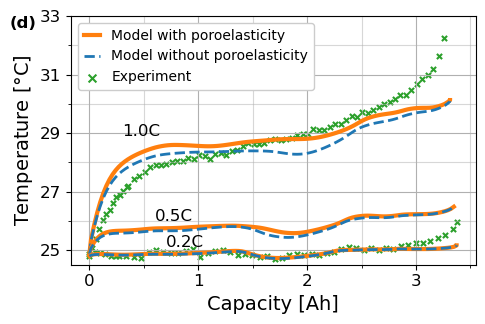

In [169]:
fig, ax = plt.subplots(1, 1,  figsize=(5, 3.4))

# 1C discharging
df_comsol = pd.read_csv(folder / "simulated_temperature_discharge_C_rate_1.csv", skiprows=8, names=["Q", "Temp"], header=None, sep=',', nrows=120)
df_comsol.Q -= df_comsol.Q.max()
df_comsol.Q *= -1
df_comsol_noflow = pd.read_csv(folder / "simulated_temperature_discharge_noflow_C_rate_1.csv", skiprows=8, names=["Q", "Temp"], header=None, sep=',', nrows=500)
df_comsol_noflow.Q -= df_comsol_noflow.Q.max()
df_comsol_noflow.Q *= -1
df_exp = pd.read_csv(folder / "measured_temperature_1C_discharge.txt", names=["Q", "Temp"], header=None, sep='       ', engine='python')
df_exp.Q *= 3.4
df_comsol.Temp -= df_comsol.Temp.iloc[0] - df_exp.Temp.iloc[0]
df_comsol_noflow.Temp -= df_comsol_noflow.Temp.iloc[0] - df_exp.Temp.iloc[0]
plt.plot(df_comsol.Q, df_comsol.Temp, label="Model with poroelasticity", color='tab:orange', linestyle='-', linewidth=3.0)
plt.plot(df_comsol_noflow.Q, df_comsol_noflow.Temp, label="Model without poroelasticity", color='tab:blue', linestyle='--', linewidth=2.0)
plt.scatter(df_exp.Q[:400:35], df_exp.Temp[:400:35], label="Experiment", marker='x', s=14, c="tab:green")
plt.scatter(df_exp.Q[400::55], df_exp.Temp[400::55], marker='x', s=14, c="tab:green")

# 0.5C discharging
df_comsol = pd.read_csv(folder / "simulated_temperature_discharge_C_rate_0.5.csv", skiprows=8, names=["Q", "Temp"], header=None, sep=',', nrows=120)
df_comsol.Q -= df_comsol.Q.max()
df_comsol.Q *= -1
df_comsol_noflow = pd.read_csv(folder / "simulated_temperature_discharge_noflow_C_rate_0.5.csv", skiprows=8, names=["Q", "Temp"], header=None, sep=',', nrows=120)
df_comsol_noflow.Q -= df_comsol_noflow.Q.max()
df_comsol_noflow.Q *= -1
df_comsol.Temp -= df_comsol.Temp.iloc[0] - df_exp.Temp.iloc[0]
df_comsol_noflow.Temp -= df_comsol_noflow.Temp.iloc[0] - df_exp.Temp.iloc[0]
plt.plot(df_comsol.Q, df_comsol.Temp, color='tab:orange', linestyle='-', linewidth=3.0)
plt.plot(df_comsol_noflow.Q, df_comsol_noflow.Temp, color='tab:blue', linestyle='--', linewidth=2.0)

# 0.2C discharging
df_comsol = pd.read_csv(folder / "simulated_temperature_discharge_C_rate_0.2.csv", skiprows=8, names=["Q", "Temp"], header=None, sep=',', nrows=125)
df_comsol.Q -= df_comsol.Q.max()
df_comsol.Q *= -1
df_comsol_noflow = pd.read_csv(folder / "simulated_temperature_discharge_noflow_C_rate_0.2.csv", skiprows=8, names=["Q", "Temp"], header=None, sep=',', nrows=125)
df_comsol_noflow.Q -= df_comsol_noflow.Q.max()
df_comsol_noflow.Q *= -1
df_exp = pd.read_csv(folder / "measured_temperature_0.2C_discharge.txt", names=["Q", "Temp"], header=None, sep='       ', engine='python')
df_exp.Q *= 3.4
df_comsol.Temp -= df_comsol.Temp.iloc[0] - df_exp.Temp.iloc[0]
df_comsol_noflow.Temp -= df_comsol_noflow.Temp.iloc[0] - df_exp.Temp.iloc[0]
plt.plot(df_comsol.Q, df_comsol.Temp, color='tab:orange', linestyle='-', linewidth=3.0)
plt.plot(df_comsol_noflow.Q, df_comsol_noflow.Temp, color='tab:blue', linestyle='--', linewidth=2.0)
plt.scatter(df_exp.Q[:300:55], df_exp.Temp[:300:55], marker='x', s=14, c="tab:green")
plt.scatter(df_exp.Q[300::75], df_exp.Temp[300::75], marker='x', s=14, c="tab:green")


plt.xlabel("Capacity [Ah]")
plt.ylabel(r"Temperature [$\degree$C]")
plt.legend(markerscale=1.5, framealpha=1, handlelength=1.2, fontsize=10)
plt.grid()
plt.text(0.3,28.9,"1.0C", color='black', fontsize=12)
plt.text(0.6,26.,"0.5C", color='black', fontsize=12)
plt.text(0.7,25.1,"0.2C", color='black', fontsize=12)
plt.yticks(np.arange(25, 33.1, step=2))
plt.xticks(np.arange(0, 3.01, step=1.0))

ax.grid(which="minor", alpha=0.5)
ax.xaxis.set_minor_locator(tck.AutoMinorLocator(n=2))
ax.yaxis.set_minor_locator(tck.AutoMinorLocator(n=2))
plt.ylim(24.5, 33)

numbering = (-0.73, "(d)")
if numbering != None:
    ax.text(numbering[0], ax.get_ylim()[1], numbering[1], weight="bold", verticalalignment="top")


plt.tight_layout()
plt.savefig("../plots/temperature_profile_verification_dch.png", format="png", dpi=500)
